# Traffic Flow Prediction — Dhaka Urban Transport Network
## Thesis: Traffic Flow Prediction and Dynamic Routing in Bangladesh's Urban Transport Networks with Graph Neural Networks


---

### Model: ST-GCN + Transformer (Graph Neural Network)

```
Dataset   : All 156,531 road edges — complete Dhaka road network
Target    : traffic_factor (congestion index 0–1), 15-min ahead prediction
Graph     : Line-graph — two edges adjacent if they share an intersection node

Architecture
------------
Input signals  x : [B, L, N]    B=batch, L=12 lookback steps (3 h), N=156,531 edges
Spatial feats  E : [N, 24]      u_lat, u_lon, v_lat, v_lon, mid_lat, mid_lon,
                                 haversine_m, length_m, free_speed, capacity,
                                 road_type (14-dim one-hot)
Temporal feats T : [T, 5]       hour_sin, hour_cos, dow_sin, dow_cos, is_weekend

Per time step t = 0 ... L-1:
  1. Signal projection      x[:,t,:]  →  [B, N, d]
  2. Add static spatial     GCN on road geometry (computed once, no batch averaging)
  3. Mean-pool over N       →  [B, d]   (global traffic state per sample)
  4. Fuse with temporal     →  step embedding  [B, d]

Transformer encoder         [B, L, d]  →  [B, L, d]
  (learns sequential patterns: AM peak, PM peak, weekly cycle)
  Context: mean pool over all L tokens (full temporal context)

Per-edge decoder            global context [B,d] + spatial [N,d]  →  [B, N, H]
```

### Why All 156,531 Edges?
Full-network GNN training is feasible on Colab A100/T4 GPU (total RAM ~2 GB).
Using all edges eliminates sampling bias and gives a complete picture of
Dhaka's spatial traffic dynamics — stronger thesis claim than any subset.

### Notebook Structure
| Cell | Content |
|------|---------|
| 1 | Install dependencies |
| 2 | Imports + keep-alive thread |
| 3 | Mount Google Drive |
| 4 | Parameters |
| 5 | Load 3 Parquet files (edges_meta, timestamps, timeseries) |
| 6 | Build Y matrix [T x N] for all edges |
| 7 | Feature engineering — temporal (sin/cos) + spatial (lat/lon) |
| 8 | Line-graph adjacency construction for GCN |
| 9 | Sliding-window Dataset + DataLoaders (on-the-fly, no OOM) |
| 10 | ST-GCN + Transformer model definition |
| 11 | Training loop — AdamW + CosineAnnealing + early stopping |
| 12 | Training curve |
| 13 | Evaluation — MAE, RMSE, MAPE on test set |
| 14 | Per-edge error distribution |
| 15 | Spatial error heatmap on Dhaka geography |
| 16 | Time-of-day error analysis (peak vs off-peak) |
| 17 | Single-edge prediction vs ground truth |
| 18 | Per-road-type performance breakdown |
| 19 | Benchmark comparison (GNN vs baselines) |
| 20 | Statistical significance testing (Diebold-Mariano + Bootstrap CI)|
| 21 | Final results table + save checkpoint to Drive|

In [2]:
# Cell 1 -- Install dependencies
!pip install -q pyarrow pandas numpy scikit-learn matplotlib seaborn tqdm
import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


In [3]:
# Cell 2 -- Imports + keep-alive thread
import os, math, warnings, random, gc, time, threading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Keep-alive: background thread prevents idle timeout on free Colab
_alive = True
def _keepalive():
    while _alive:
        _ = 1 + 1
        time.sleep(60)
_t = threading.Thread(target=_keepalive, daemon=True)
_t.start()
print('Keep-alive thread started.')


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
Keep-alive thread started.


In [4]:
# Cell 3 -- Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Cell 4 -- Parameters
# Change BASE_DIR to the folder in your Drive that contains the 3 parquet files
BASE_DIR = '/content/drive/MyDrive/traffic_flow_prediction'

EDGES_META_PATH = os.path.join(BASE_DIR, 'tfp_edges_meta.parquet')
TIMESTAMPS_PATH = os.path.join(BASE_DIR, 'tfp_timestamps.parquet')
TIMESERIES_PATH = os.path.join(BASE_DIR, 'tfp_traffic_timeseries.parquet')

for p in [EDGES_META_PATH, TIMESTAMPS_PATH, TIMESERIES_PATH]:
    sz = os.path.getsize(p) / 1e6 if os.path.exists(p) else -1
    status = f'{sz:.1f} MB' if sz >= 0 else '!! NOT FOUND !!'
    print(f'  {os.path.basename(p):45s}  {status}')

# Prediction configuration
PREDICTION_TARGET = 'traffic_factor'   # 'traffic_factor' | 'current_speed_kmh' | 'travel_time_s'
LOOKBACK          = 12                 # 12 x 15 min = 3 h history
HORIZON           = 1                  # predict next 15 min

# Model configuration
D_MODEL      = 64
N_HEADS      = 8
N_LAYERS     = 3
DROPOUT      = 0.1

# Training configuration
BATCH_SIZE   = 32
EPOCHS       = 100
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 10

# Use ALL edges — complete Dhaka road network
# Memory estimate: ~2 GB total GPU RAM — feasible on Colab T4/A100
MAX_EDGES = None   # None = all 156,531 edges

print(f'\nTarget    : {PREDICTION_TARGET}')
print(f'Lookback  : {LOOKBACK} steps  ({LOOKBACK * 15} min)')
print(f'Horizon   : {HORIZON} step   ({HORIZON * 15} min ahead)')
print(f'MAX_EDGES : {MAX_EDGES}  (None = all edges in Dhaka network)')
print(f'D_MODEL={D_MODEL}  N_HEADS={N_HEADS}  N_LAYERS={N_LAYERS}  BATCH={BATCH_SIZE}')


  tfp_edges_meta.parquet                         7.5 MB
  tfp_timestamps.parquet                         0.0 MB
  tfp_traffic_timeseries.parquet                 1564.6 MB

Target    : traffic_factor
Lookback  : 12 steps  (180 min)
Horizon   : 1 step   (15 min ahead)
MAX_EDGES : None  (None = all edges in Dhaka network)
D_MODEL=64  N_HEADS=8  N_LAYERS=3  BATCH=32


In [5]:
# Cell 5 -- Load Parquet files
print('Loading edges_meta ...')
edges_meta = pd.read_parquet(EDGES_META_PATH, engine='pyarrow')
print(f'  edges_meta : {edges_meta.shape}  cols={list(edges_meta.columns)}')

print('Loading timestamps ...')
timestamps = pd.read_parquet(TIMESTAMPS_PATH, engine='pyarrow')
timestamps['timestamp'] = pd.to_datetime(timestamps['timestamp'])
print(f'  timestamps : {timestamps.shape}')

print('Loading traffic_timeseries (1–2 min) ...')
t0 = time.time()
ts_raw = pd.read_parquet(TIMESERIES_PATH, engine='pyarrow')
print(f'  timeseries : {ts_raw.shape}  loaded in {time.time()-t0:.1f}s')

display(edges_meta.head(3))
display(timestamps.head(3))
display(ts_raw.head(3))


Loading edges_meta ...
  edges_meta : (156531, 15)  cols=['eidx', 'edge_id', 'u', 'v', 'u_lat', 'u_lon', 'v_lat', 'v_lon', 'mid_lat', 'mid_lon', 'haversine_m', 'road_type', 'length_m', 'free_speed_kmh', 'capacity_factor']
Loading timestamps ...
  timestamps : (672, 6)
Loading traffic_timeseries (1–2 min) ...
  timeseries : (105188832, 5)  loaded in 13.6s


,eidx,edge_id,u,v,u_lat,u_lon,v_lat,v_lon,mid_lat,mid_lon,haversine_m,road_type,length_m,free_speed_kmh,capacity_factor
0,0,60917111_6139734068_0,60917111,6139734068,23.727516,90.420158,23.727055,90.420891,23.727285,90.420525,91.086182,primary,91.099998,50.0,0.75
1,1,60917111_387810798_0,60917111,387810798,23.727516,90.420158,23.727978,90.420448,23.727747,90.420303,59.390030,unclassified,59.400002,25.0,0.50
2,2,60917472_10016425303_0,60917472,10016425303,23.738119,90.395950,23.738068,90.395943,23.738092,90.395950,5.912888,secondary,5.900000,40.0,0.65


,ts_idx,timestamp,dow,hour,minute,is_weekend
0,0,2025-01-06 00:00:00+06:00,0,0,0,0
1,1,2025-01-06 00:15:00+06:00,0,0,15,0
2,2,2025-01-06 00:30:00+06:00,0,0,30,0


,ts_idx,eidx,travel_time_s,current_speed_kmh,traffic_factor
0,0,0,7.717950,42.493145,0.187671
1,0,1,9.651331,22.156528,0.142174
2,0,2,0.638202,33.280998,0.209969


In [6]:
# Cell 6 -- Build Y matrix [T x N] for all edges
N_TS     = len(timestamps)
all_eidx = edges_meta['eidx'].values

if MAX_EDGES is not None and MAX_EDGES < len(all_eidx):
    rng      = np.random.default_rng(SEED)
    sel_eidx = rng.choice(all_eidx, size=MAX_EDGES, replace=False)
    sel_set  = set(int(x) for x in sel_eidx)
    edges_meta = edges_meta[edges_meta['eidx'].isin(sel_set)].reset_index(drop=True)
    edges_meta['eidx'] = np.arange(len(edges_meta), dtype=np.uint32)
    old_to_new = {int(o): int(n) for n, o in enumerate(sel_eidx)}
    ts_raw = ts_raw[ts_raw['eidx'].isin(sel_set)].copy()
    ts_raw['eidx'] = ts_raw['eidx'].map(old_to_new).astype(np.uint32)
    print(f'Sampled {len(edges_meta):,} / {len(all_eidx):,} edges')
else:
    print(f'Using ALL {len(edges_meta):,} edges — complete Dhaka road network')

N_EDGES     = len(edges_meta)
edge_order  = edges_meta.sort_values('eidx')['eidx'].tolist()
eidx_to_col = {eid: col for col, eid in enumerate(edge_order)}
N = N_EDGES
T = N_TS

est_mb = T * N * 4 / 1e6
print(f'Y matrix : [{T} x {N}] = {T*N:,} float32 values  ({est_mb:.0f} MB)')

Y_np = np.full((T, N), np.nan, dtype=np.float32)
CHUNK = 2_000_000
for start in tqdm(range(0, len(ts_raw), CHUNK), desc='Building Y matrix'):
    ch  = ts_raw.iloc[start: start + CHUNK]
    ti  = ch['ts_idx'].to_numpy(np.int32)
    ei  = ch['eidx'].to_numpy(np.int32)
    val = ch[PREDICTION_TARGET].to_numpy(np.float32)
    ci  = np.array([eidx_to_col.get(int(e), -1) for e in ei], dtype=np.int32)
    ok  = ci >= 0
    Y_np[ti[ok], ci[ok]] = val[ok]

del ts_raw; gc.collect()

nan_mask = np.isnan(Y_np)
if nan_mask.any():
    nan_cols = nan_mask.any(axis=0).sum()
    print(f'NaN columns: {nan_cols}/{N} — applying interpolation')
    col_medians = np.nanmedian(Y_np, axis=0)
    col_medians = np.where(np.isfinite(col_medians), col_medians, 0.0)
    nan_col_idx = np.where(nan_mask.any(axis=0))[0]
    for c in nan_col_idx:
        Y_np[nan_mask[:, c], c] = col_medians[c]
else:
    print(f'NaN columns: 0/{N} — no imputation needed')

print(f'Y stats — min={Y_np.min():.3f}  mean={Y_np.mean():.3f}  max={Y_np.max():.3f}')

Using ALL 156,531 edges — complete Dhaka road network
Y matrix : [672 x 156531] = 105,188,832 float32 values  (421 MB)


Building Y matrix:   0%|          | 0/53 [00:00<?, ?it/s]

NaN columns: 0/156531 — no imputation needed
Y stats — min=0.050  mean=0.479  max=1.000


In [7]:
# Cell 7 -- Feature engineering: temporal (sin/cos) + spatial (lat/lon)
import torch.nn.functional as F_func

# Temporal features [T, 5]: cyclical encoding captures daily and weekly patterns
# Minute sin/cos removed — at 15-min resolution these are redundant with hour encoding
ts_feat = timestamps.set_index('ts_idx').reindex(range(N_TS))

T_feat = np.stack([
    np.sin(2 * np.pi * ts_feat['hour'].values / 24).astype(np.float32),   # hour sin
    np.cos(2 * np.pi * ts_feat['hour'].values / 24).astype(np.float32),   # hour cos
    np.sin(2 * np.pi * ts_feat['dow'].values  /  7).astype(np.float32),   # day-of-week sin
    np.cos(2 * np.pi * ts_feat['dow'].values  /  7).astype(np.float32),   # day-of-week cos
    ts_feat['is_weekend'].values.astype(np.float32),                        # weekend flag
], axis=1)  # [T, 5]

# Spatial + road features [N, 24]: one-hot road type replaces ordinal encoding
meta_ord = edges_meta.set_index('eidx').reindex(edge_order).reset_index()

def norm(a, lo, hi):
    return ((a - lo) / (hi - lo + 1e-9)).astype(np.float32)

# Keep as named variables — Cell 8 uses these for line-graph edge weights
mid_lat_n = norm(meta_ord['mid_lat'].values, 23.60, 23.95)
mid_lon_n = norm(meta_ord['mid_lon'].values, 90.25, 90.55)

road_types_all = [
    'living_street', 'motorway', 'motorway_link', 'primary', 'primary_link',
    'residential', 'road', 'secondary', 'secondary_link', 'tertiary',
    'tertiary_link', 'trunk', 'trunk_link', 'unclassified'
]
rt_series  = meta_ord['road_type'].astype(str)
rt_dummies = pd.get_dummies(rt_series, prefix='rt').reindex(
    columns=[f'rt_{r}' for r in road_types_all], fill_value=0
).astype(np.float32).values   # [N, 14]

E_feat = np.concatenate([
    norm(meta_ord['u_lat'].values,    23.60, 23.95).reshape(-1, 1),
    norm(meta_ord['u_lon'].values,    90.25, 90.55).reshape(-1, 1),
    norm(meta_ord['v_lat'].values,    23.60, 23.95).reshape(-1, 1),
    norm(meta_ord['v_lon'].values,    90.25, 90.55).reshape(-1, 1),
    mid_lat_n.reshape(-1, 1),
    mid_lon_n.reshape(-1, 1),
    (meta_ord['haversine_m'].values /
     (meta_ord['haversine_m'].max() + 1e-9)).reshape(-1, 1).astype(np.float32),
    (meta_ord['length_m'].values /
     (meta_ord['length_m'].max() + 1e-9)).reshape(-1, 1).astype(np.float32),
    (meta_ord['free_speed_kmh'].values /
     (meta_ord['free_speed_kmh'].max() + 1e-9)).reshape(-1, 1).astype(np.float32),
    meta_ord['capacity_factor'].values.reshape(-1, 1).astype(np.float32),
    rt_dummies,
], axis=1)   # [N, 24]

n_edge_feat = E_feat.shape[1]   # 24
n_time_feat = T_feat.shape[1]   # 5

print(f'Temporal features : {T_feat.shape}')
print(f'Spatial features  : {E_feat.shape}')
print(f'Road types        : {road_types_all}')

Temporal features : (672, 5)
Spatial features  : (156531, 24)
Road types        : ['living_street', 'motorway', 'motorway_link', 'primary', 'primary_link', 'residential', 'road', 'secondary', 'secondary_link', 'tertiary', 'tertiary_link', 'trunk', 'trunk_link', 'unclassified']


In [8]:
# Cell 8 -- Line-graph adjacency for GCN
#
# Line-graph construction:
#   Nodes  = road segments (edges in OSM graph)
#   Edges  = connectivity between road segments sharing an intersection
#   Weight = 1 / haversine_distance(midpoint_a, midpoint_b)
#            (nearby segments are more strongly connected)
# Normalisation: D^{-1/2} A D^{-1/2}  (Kipf & Welling, 2017)

u_nodes = meta_ord['u'].values
v_nodes = meta_ord['v'].values

print('Building line-graph adjacency ...')
node_to_edges = defaultdict(list)
for i, (u, v) in enumerate(zip(u_nodes, v_nodes)):
    node_to_edges[u].append(i)
    node_to_edges[v].append(i)

src_list, dst_list, w_list = [], [], []
for node, elist in node_to_edges.items():
    elist = list(set(elist))
    for i in range(len(elist)):
        for j in range(len(elist)):
            if i == j:
                continue
            a, b = elist[i], elist[j]
            dlat = float(mid_lat_n[a] - mid_lat_n[b])
            dlon = float(mid_lon_n[a] - mid_lon_n[b])
            w_list.append(1.0 / (math.sqrt(dlat**2 + dlon**2) + 1e-6))
            src_list.append(a)
            dst_list.append(b)

if not src_list:
    src_list = dst_list = list(range(N_EDGES))
    w_list = [1.0] * N_EDGES

src_arr = np.array(src_list, dtype=np.int64)
dst_arr = np.array(dst_list, dtype=np.int64)
w_arr   = np.array(w_list,   dtype=np.float32)

# Add self-loops (standard in GCN)
sl      = np.arange(N_EDGES, dtype=np.int64)
src_arr = np.concatenate([src_arr, sl])
dst_arr = np.concatenate([dst_arr, sl])
w_arr   = np.concatenate([w_arr, np.ones(N_EDGES, dtype=np.float32)])

# D^{-1/2} A D^{-1/2} normalisation
deg      = np.bincount(src_arr, weights=w_arr, minlength=N_EDGES).astype(np.float32)
d_inv_sq = np.where(deg > 0, 1.0 / np.sqrt(deg), 0.0)
w_norm   = (w_arr * d_inv_sq[src_arr] * d_inv_sq[dst_arr]).astype(np.float32)

edge_index_t  = torch.tensor(np.stack([src_arr, dst_arr]), dtype=torch.long)
edge_weight_t = torch.tensor(w_norm, dtype=torch.float32)

A_sparse = torch.sparse_coo_tensor(
    edge_index_t, edge_weight_t,
    (N_EDGES, N_EDGES), dtype=torch.float32
).coalesce()

print(f'Line-graph nodes   : {N_EDGES:,}  (road segments)')
print(f'Line-graph edges   : {edge_index_t.shape[1]:,}  (including self-loops)')
print(f'Avg. degree        : {edge_index_t.shape[1] / N_EDGES:.1f}')
print(f'Sparse adj (nnz)   : {A_sparse._nnz():,}  — O(nnz) GCN, not O(N^2)')


Building line-graph adjacency ...
Line-graph nodes   : 156,531  (road segments)
Line-graph edges   : 1,632,817  (including self-loops)
Avg. degree        : 10.4
Sparse adj (nnz)   : 1,483,741  — O(nnz) GCN, not O(N^2)


In [9]:
# Cell 9 -- Normalise Y + on-the-fly sliding-window Dataset
#
# SlidingWindowDataset creates one window per __getitem__ call.
# No giant pre-built [B, L, N] array is ever allocated -> no OOM risk.

# Temporal split indices
t_train = int(0.70 * T)   # 70% train
t_val   = int(0.85 * T)   # 15% val, 15% test

# Normalization statistics computed ONLY on training split (no data leakage)
Y_train_block = Y_np[:t_train]                              # [t_train, N]
y_mean = Y_train_block.mean(axis=0, keepdims=True).astype(np.float32)   # [1, N]
y_std  = Y_train_block.std(axis=0,  keepdims=True).astype(np.float32)
y_std  = np.where(y_std < 1e-6, 1e-6, y_std)

# Apply train statistics to all splits
Yz = ((Y_np - y_mean) / y_std).astype(np.float32)
del Y_np; gc.collect()

Ytr, Ttr = Yz[:t_train],      T_feat[:t_train]
Yva, Tva = Yz[t_train:t_val], T_feat[t_train:t_val]
Yte, Tte = Yz[t_val:],        T_feat[t_val:]

print(f'Train / Val / Test timesteps : {len(Ytr)} / {len(Yva)} / {len(Yte)}')
print(f'y_mean range : [{y_mean.min():.4f}, {y_mean.max():.4f}]')
print(f'y_std  range : [{y_std.min():.4f},  {y_std.max():.4f}]')


class SlidingWindowDataset(Dataset):
    '''
    On-the-fly sliding window dataset.
    Stores only the base arrays; each window is sliced on __getitem__.
    Memory: just the split Y block — no window pre-building.
    '''
    def __init__(self, Y, Tf, lookback, horizon):
        self.Y, self.Tf = Y, Tf
        self.L, self.H  = lookback, horizon
        self.n = max(0, len(Y) - lookback - horizon + 1)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        t0 = idx + self.L
        x  = torch.from_numpy(self.Y [t0 - self.L : t0].copy())   # [L, N]
        xt = torch.from_numpy(self.Tf[t0 - self.L : t0].copy())   # [L, 5]
        y  = torch.from_numpy(self.Y [t0 : t0 + self.H].copy())   # [H, N]
        return x, xt, y


train_ds = SlidingWindowDataset(Ytr, Ttr, LOOKBACK, HORIZON)
val_ds   = SlidingWindowDataset(Yva, Tva, LOOKBACK, HORIZON)
test_ds  = SlidingWindowDataset(Yte, Tte, LOOKBACK, HORIZON)

_nw = 2 if device.type == 'cuda' else 0
_pm = device.type == 'cuda'
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=_nw, pin_memory=_pm)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pm)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=_nw, pin_memory=_pm)

xb, xtb, yb = next(iter(train_loader))
print(f'Train windows : {len(train_ds)}  ({len(train_loader)} batches)')
print(f'Val   windows : {len(val_ds)}')
print(f'Test  windows : {len(test_ds)}')
print(f'Batch shapes  : x={tuple(xb.shape)}  x_time={tuple(xtb.shape)}  y={tuple(yb.shape)}')


Train / Val / Test timesteps : 470 / 101 / 101
y_mean range : [0.4227, 0.5347]
y_std  range : [0.2764,  0.3192]
Train windows : 458  (15 batches)
Val   windows : 89
Test  windows : 89
Batch shapes  : x=(32, 12, 156531)  x_time=(32, 12, 5)  y=(32, 1, 156531)


In [10]:
# Cell 10 -- ST-GCN + Transformer Model
#
# References:
#   GCN: Kipf & Welling (2017) "Semi-Supervised Classification with GCN"
#   STGCN: Yu et al. (2018) "Spatio-Temporal Graph Convolutional Networks"
#   Spatial-Temporal Transformer: Xu et al. (2020)
#
# Architecture:
#   1. GCN operates on static spatial embeddings (road geometry), not on
#      dynamic traffic signals. This correctly separates structural and
#      temporal information.
#   2. Transformer encodes L timestep embeddings [B, L, d] — memory-efficient.
#   3. Mean pooling over all L Transformer tokens uses the full temporal context.
#   4. Decoder combines global temporal context [B,d] with per-edge spatial
#      embeddings [N,d] to produce per-edge predictions [B, N, H].


class SparseGCNLayer(nn.Module):
    '''
    Graph Convolutional Layer (Kipf & Welling, 2017).
    Operates on the road segment line-graph.

    Uses sparse COO adjacency: memory scales as O(nnz), not O(N^2).
    For N=156k with avg degree ~5: nnz~780k vs dense N^2=24B elements.

    Forward: A_hat * (X * W)   where A_hat = D^{-1/2} A D^{-1/2}
    '''
    def __init__(self, A_sparse, in_dim, out_dim):
        super().__init__()
        self.lin  = nn.Linear(in_dim, out_dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_dim))
        idx = A_sparse.coalesce().indices()
        val = A_sparse.coalesce().values()
        self.register_buffer('A_idx', idx)
        self.register_buffer('A_val', val)
        self.N = A_sparse.size(0)

    def forward(self, x):
        '''x : [N, d_in]  ->  [N, d_out]'''
        A   = torch.sparse_coo_tensor(
            self.A_idx, self.A_val,
            (self.N, self.N), device=x.device
        ).coalesce()
        xw  = self.lin(x)
        return torch.sparse.mm(A, xw) + self.bias


class STGCNTransformer(nn.Module):
    '''
    Spatio-Temporal GCN + Transformer for Traffic Flow Prediction.

    Operates on ALL N road segments simultaneously.

    Forward pass shapes (B=32, L=12, N=156531, d=64):
      x input          : [32, 12, 156531]
      Static GCN path  : [156531, 64]  sparse mm on road geometry (once per forward)
      Dynamic path     : [32, 12, 64]  per-sample signal projections
      Transformer      : [32, 12, 64]
      Output           : [32, 1, 156531]
    '''
    def __init__(self, N, A_sparse, E_feat_np,
                 lookback, horizon,
                 n_edge_feat=24, n_time_feat=5,
                 d_model=64, n_heads=8, n_layers=3, dropout=0.1):
        super().__init__()
        self.L, self.H, self.N = lookback, horizon, N

        # Spatial embedding: static road geometry -> d_model
        self.edge_emb = nn.Sequential(
            nn.Linear(n_edge_feat, d_model), nn.GELU(),
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
        )
        self.register_buffer('E_feat', torch.tensor(E_feat_np, dtype=torch.float32))

        # GCN on static spatial embeddings (road topology propagation)
        self.gcn      = SparseGCNLayer(A_sparse, d_model, d_model)
        self.gcn_norm = nn.LayerNorm(d_model)

        # Per-step signal projection: dynamic (per-sample) path
        self.sig_proj  = nn.Linear(1, d_model)
        self.time_proj = nn.Linear(n_time_feat, d_model)
        self.step_proj = nn.Linear(d_model * 2, d_model)
        self.step_norm = nn.LayerNorm(d_model)

        # Transformer encoder: temporal pattern learning over L steps
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc, num_layers=n_layers)

        # Per-edge prediction decoder
        self.dec_ctx  = nn.Linear(d_model, d_model)
        self.dec_head = nn.Sequential(
            nn.Linear(d_model * 2, d_model), nn.GELU(),
            nn.Linear(d_model, horizon),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x, x_time):
        '''
        x      : [B, L, N]   normalised traffic signals (per-sample, distinct)
        x_time : [B, L, 5]   temporal features (sin/cos hour, dow, weekend)
        Returns: [B, H, N]   predictions H steps ahead for all N edges
        '''
        B, L, N = x.shape

        # Static spatial path: GCN on road geometry (no dynamic signals involved)
        sp_raw = self.edge_emb(self.E_feat)               # [N, d]
        sp     = self.gcn_norm(self.gcn(sp_raw) + sp_raw) # [N, d]

        # Dynamic per-sample temporal path
        steps = []
        for t in range(L):
            sig_t  = x[:, t, :]                            # [B, N]
            sig_e  = self.sig_proj(sig_t.unsqueeze(-1))    # [B, N, d]

            # Add static spatial context via broadcast (no cross-batch averaging)
            sig_sp = sig_e + sp.unsqueeze(0)               # [B, N, d]

            # Pool to global state per sample
            pooled = sig_sp.mean(dim=1)                    # [B, d]

            # Fuse with temporal features
            t_emb = self.time_proj(x_time[:, t, :])        # [B, d]
            step  = self.step_norm(
                self.step_proj(torch.cat([pooled, t_emb], dim=-1)))  # [B, d]
            steps.append(step)

        # Transformer over L time steps
        h   = torch.stack(steps, dim=1)   # [B, L, d]
        h   = self.transformer(h)          # [B, L, d]

        # Mean pool over all L tokens — uses full temporal context
        ctx = h.mean(dim=1)               # [B, d]

        # Decode per-edge predictions
        ctx_e = self.dec_ctx(ctx).unsqueeze(1).expand(-1, N, -1)   # [B, N, d]
        sp_e  = sp.unsqueeze(0).expand(B, -1, -1)                  # [B, N, d]
        out   = self.dec_head(self.drop(
            torch.cat([ctx_e, sp_e], dim=-1)))                      # [B, N, H]
        return out.permute(0, 2, 1)                                 # [B, H, N]


# Instantiate model
A_sparse_dev = A_sparse.to(device)

model = STGCNTransformer(
    N           = N_EDGES,
    A_sparse    = A_sparse_dev,
    E_feat_np   = E_feat,
    lookback    = LOOKBACK,
    horizon     = HORIZON,
    n_edge_feat = n_edge_feat,
    n_time_feat = n_time_feat,
    d_model     = D_MODEL,
    n_heads     = N_HEADS,
    n_layers    = N_LAYERS,
    dropout     = DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model    : ST-GCN + Transformer')
print(f'Params   : {n_params:,}')
print(f'N_edges  : {N_EDGES:,}  |  d={D_MODEL}  heads={N_HEADS}  layers={N_LAYERS}')

# Forward pass timing
_xb, _xtb, _ = next(iter(train_loader))
with torch.no_grad():
    model(_xb.to(device), _xtb.to(device))   # warmup
t0 = time.time()
with torch.no_grad():
    for _ in range(3):
        _out = model(_xb.to(device), _xtb.to(device))
ms = (time.time() - t0) / 3 * 1000
print(f'Forward  : {tuple(_xb.shape)} -> {tuple(_out.shape)}')
print(f'Avg time : {ms:.0f} ms/batch  |  Est. epoch ~{ms * len(train_loader) / 1000 / 60:.1f} min')
del _xb, _xtb, _out; gc.collect()


Model    : ST-GCN + Transformer
Params   : 181,505
N_edges  : 156,531  |  d=64  heads=8  layers=3
Forward  : (32, 12, 156531) -> (32, 1, 156531)
Avg time : 412 ms/batch  |  Est. epoch ~0.1 min


0

In [11]:
# Cell 11 -- Training loop: AdamW + warmup + cosine decay + early stopping
WARMUP_STEPS = int(0.1 * EPOCHS * len(train_loader))   # 10% warmup

def get_lr_with_warmup(step, warmup_steps, d_model=D_MODEL):
    '''Transformer-style linear warmup followed by cosine decay.'''
    if step < warmup_steps:
        return step / max(warmup_steps, 1)
    progress = (step - warmup_steps) / max(EPOCHS * len(train_loader) - warmup_steps, 1)
    return max(1e-5 / LR, 0.5 * (1 + math.cos(math.pi * progress)))

optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda step: get_lr_with_warmup(step, WARMUP_STEPS)
)
loss_fn    = nn.HuberLoss(delta=1.0)

global_step = 0
train_losses, val_losses = [], []
best_val, best_state, patience_ctr = float('inf'), None, 0
total_start = time.time()

print(f"{'Epoch':>5}  {'Train':>9}  {'Val':>9}  {'LR':>9}  {'Time':>6}  {'Best':>4}")
print('-' * 55)

for epoch in range(1, EPOCHS + 1):
    t_ep = time.time()

    model.train()
    tr_sum, tr_n = 0.0, 0
    for xb, xtb, yb in train_loader:
        xb, xtb, yb = xb.to(device), xtb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(xb, xtb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()    # step per batch for warmup schedule
        global_step += 1
        tr_sum += loss.item() * xb.size(0)
        tr_n   += xb.size(0)
    tr_loss = tr_sum / max(tr_n, 1)

    model.eval()
    va_sum, va_n = 0.0, 0
    with torch.no_grad():
        for xb, xtb, yb in val_loader:
            xb, xtb, yb = xb.to(device), xtb.to(device), yb.to(device)
            va_sum += loss_fn(model(xb, xtb), yb).item() * xb.size(0)
            va_n   += xb.size(0)
    va_loss = va_sum / max(va_n, 1)

    ep_sec  = time.time() - t_ep
    cur_lr  = optimizer.param_groups[0]['lr']
    is_best = va_loss < best_val - 1e-5

    if is_best:
        best_val     = va_loss
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    mark = ' *' if is_best else ''
    print(f'{epoch:>5}  {tr_loss:>9.4f}  {va_loss:>9.4f}  '
          f'{cur_lr:>9.6f}  {ep_sec:>5.1f}s{mark}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch}  (best val={best_val:.4f})')
        break

if best_state is not None:
    model.load_state_dict(best_state)
elapsed = time.time() - total_start
print(f'\nTraining complete.  Best val loss: {best_val:.4f}  Total time: {elapsed/60:.1f} min')


Epoch      Train        Val         LR    Time  Best
-------------------------------------------------------
    1     0.4120     0.2810   0.000100   19.4s *
    2     0.3175     0.2155   0.000200   17.9s *
    3     0.2692     0.1829   0.000300   19.5s *
    4     0.2478     0.2283   0.000400   18.1s
    5     0.2225     0.1487   0.000500   18.2s *
    6     0.1410     0.0928   0.000600   18.4s *
    7     0.1103     0.0819   0.000700   19.1s *
    8     0.0944     0.0878   0.000800   18.2s
    9     0.0948     0.1265   0.000900   18.4s
   10     0.0837     0.0741   0.001000   19.1s *
   11     0.0880     0.0869   0.001000   18.5s
   12     0.0810     0.0763   0.000999   18.4s
   13     0.0803     0.0787   0.000997   18.4s
   14     0.0809     0.0744   0.000995   19.2s
   15     0.0745     0.0700   0.000992   18.4s *
   16     0.0746     0.0835   0.000989   18.3s
   17     0.0741     0.0716   0.000985   19.3s
   18     0.0684     0.0674   0.000981   18.3s *
   19     0.0726     0.0856

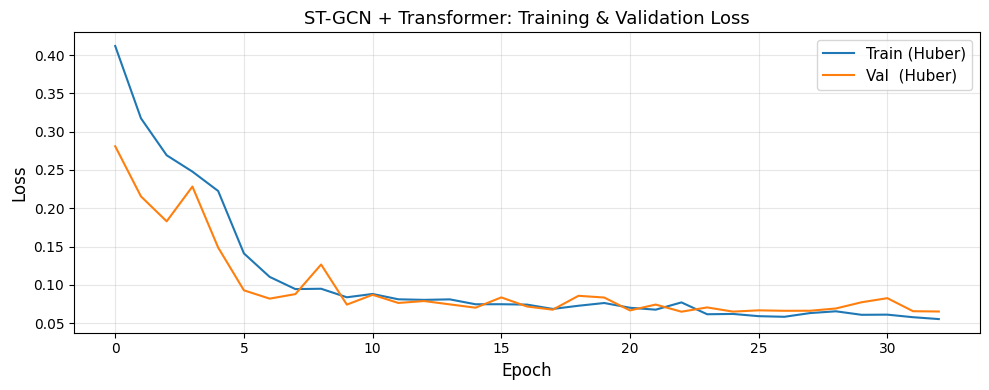

Saved: tfp_training_curve.png


In [12]:
# Cell 12 -- Training curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train (Huber)', lw=1.5)
ax.plot(val_losses,   label='Val  (Huber)',  lw=1.5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss',  fontsize=12)
ax.set_title('ST-GCN + Transformer: Training & Validation Loss', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tfp_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tfp_training_curve.png')


In [13]:
# Cell 13 -- Evaluation on test set
model.eval()
preds_list, trues_list = [], []
with torch.no_grad():
    for xb, xtb, yb in tqdm(test_loader, desc='Evaluating'):
        pred = model(xb.to(device), xtb.to(device)).cpu()
        preds_list.append(pred[:, 0, :].numpy())
        trues_list.append(yb[:, 0, :].numpy())

preds_norm = np.concatenate(preds_list, axis=0)   # [T_test, N]
trues_norm = np.concatenate(trues_list, axis=0)

preds_raw = preds_norm * y_std[0] + y_mean[0]
trues_raw = trues_norm * y_std[0] + y_mean[0]
if PREDICTION_TARGET == 'traffic_factor':
    preds_raw = np.clip(preds_raw, 0.0, 1.0)
elif PREDICTION_TARGET in ('current_speed_kmh', 'travel_time_s'):
    preds_raw = np.maximum(preds_raw, 0.0)

mae  = mean_absolute_error(trues_raw.flatten(), preds_raw.flatten())
rmse = np.sqrt(mean_squared_error(trues_raw.flatten(), preds_raw.flatten()))
mask = np.abs(trues_raw) > 1e-3
mape = np.mean(np.abs((trues_raw[mask] - preds_raw[mask]) / trues_raw[mask])) * 100

print('=' * 60)
print(f'  Test Set Results  --  {PREDICTION_TARGET}')
print(f'  N_edges : {N_EDGES:,}  (complete Dhaka road network)')
print('=' * 60)
print(f'  MAE  : {mae:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAPE : {mape:.2f} %')
print(f'  Pred range : [{preds_raw.min():.3f}, {preds_raw.max():.3f}]')
print(f'  True range : [{trues_raw.min():.3f}, {trues_raw.max():.3f}]')


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

  Test Set Results  --  traffic_factor
  N_edges : 156,531  (complete Dhaka road network)
  MAE  : 0.0837
  RMSE : 0.1141
  MAPE : 29.31 %
  Pred range : [0.095, 1.000]
  True range : [0.050, 1.000]


Per-edge MAE  : mean=0.0837  median=0.0835  p95=0.0944
Per-edge RMSE : mean=0.1138  median=0.1137  p95=0.1254


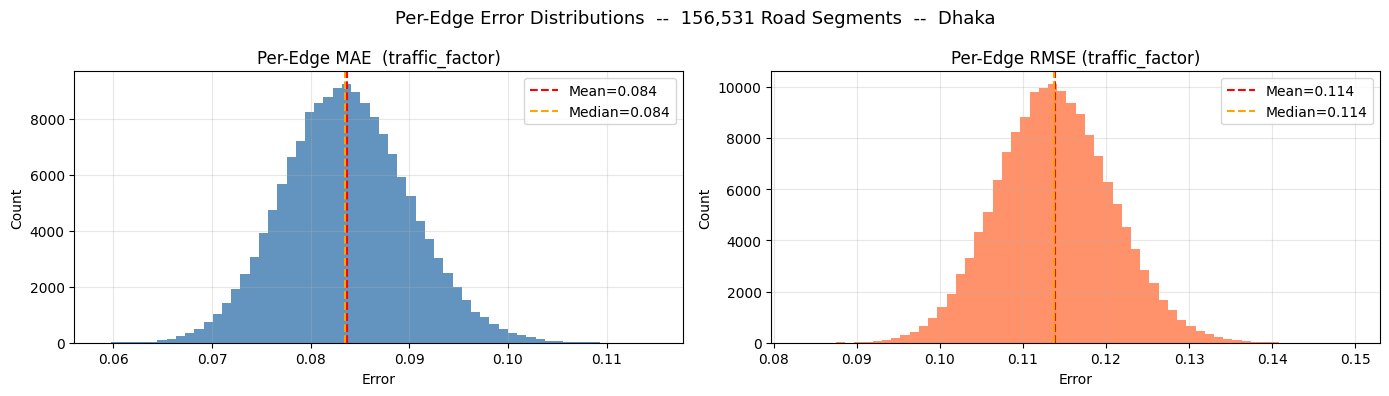

In [14]:
# Cell 14 -- Per-edge error distributions
per_edge_mae  = np.mean(np.abs(trues_raw - preds_raw), axis=0)
per_edge_rmse = np.sqrt(np.mean((trues_raw - preds_raw) ** 2, axis=0))

print(f'Per-edge MAE  : mean={per_edge_mae.mean():.4f}  '
      f'median={np.median(per_edge_mae):.4f}  '
      f'p95={np.percentile(per_edge_mae, 95):.4f}')
print(f'Per-edge RMSE : mean={per_edge_rmse.mean():.4f}  '
      f'median={np.median(per_edge_rmse):.4f}  '
      f'p95={np.percentile(per_edge_rmse, 95):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, vals, color, title in [
    (axes[0], per_edge_mae,  'steelblue', f'Per-Edge MAE  ({PREDICTION_TARGET})'),
    (axes[1], per_edge_rmse, 'coral',     f'Per-Edge RMSE ({PREDICTION_TARGET})'),
]:
    ax.hist(vals, bins=60, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(vals.mean(),        color='red',    ls='--', lw=1.5, label=f'Mean={vals.mean():.3f}')
    ax.axvline(np.median(vals),    color='orange', ls='--', lw=1.5, label=f'Median={np.median(vals):.3f}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Error'); ax.set_ylabel('Count')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle(f'Per-Edge Error Distributions  --  {N_EDGES:,} Road Segments  --  Dhaka', fontsize=13)
plt.tight_layout()
plt.savefig('tfp_per_edge_error_dist.png', dpi=150, bbox_inches='tight')
plt.show()


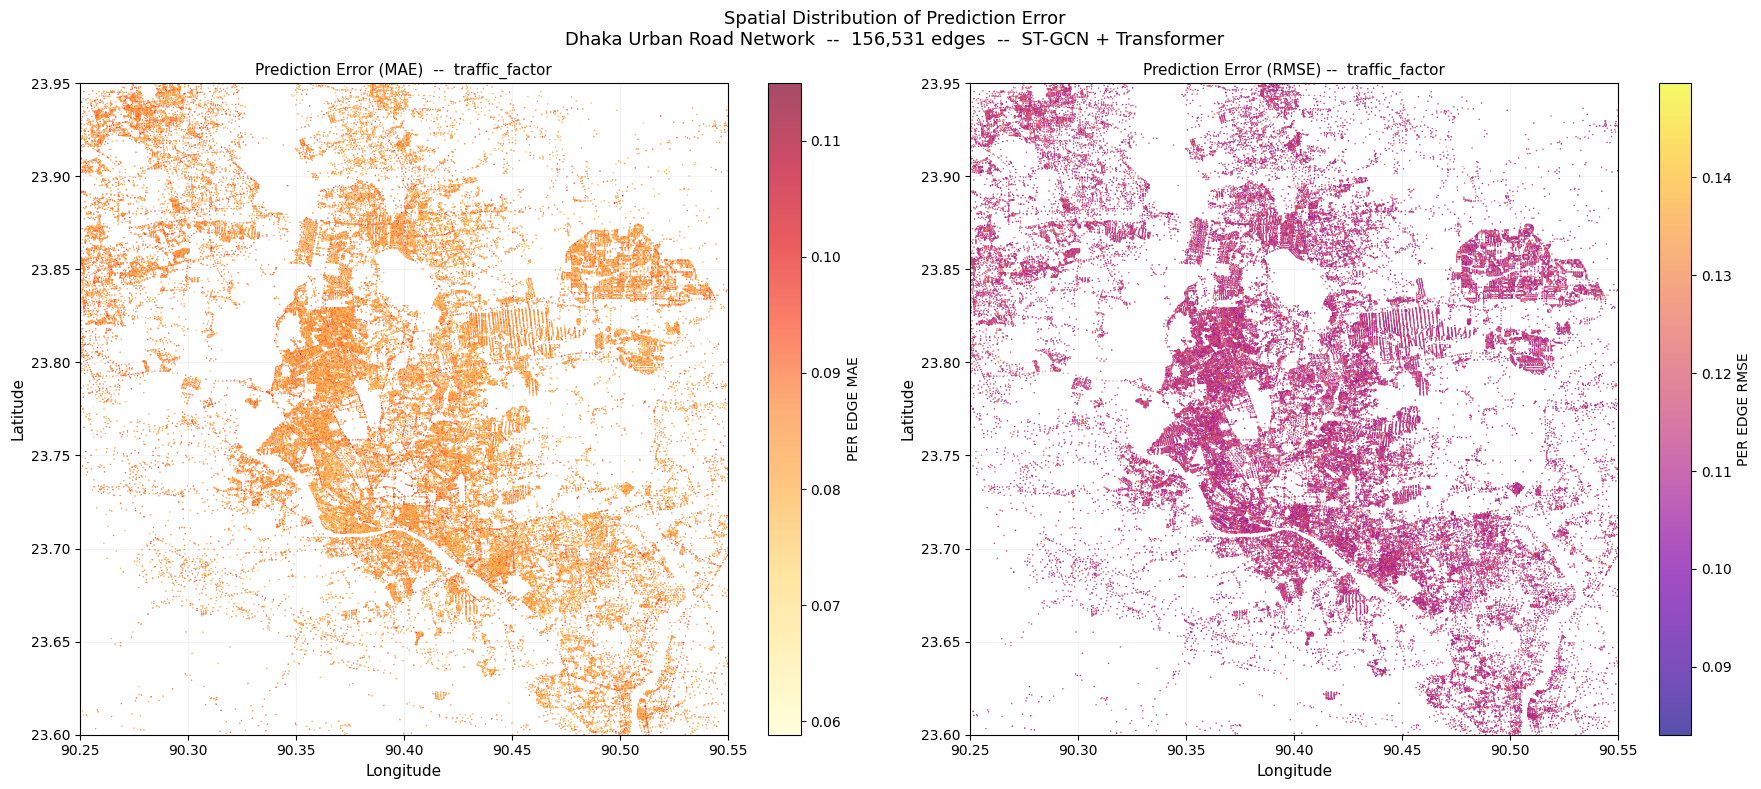

In [15]:
# Cell 15 -- Spatial error heatmap on Dhaka road map
meta_plot = edges_meta.set_index('eidx').reindex(edge_order).reset_index()
meta_plot['per_edge_mae']  = per_edge_mae
meta_plot['per_edge_rmse'] = per_edge_rmse

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, col, cmap, title in [
    (axes[0], 'per_edge_mae',  'YlOrRd', f'Prediction Error (MAE)  --  {PREDICTION_TARGET}'),
    (axes[1], 'per_edge_rmse', 'plasma',  f'Prediction Error (RMSE) --  {PREDICTION_TARGET}'),
]:
    sc = ax.scatter(
        meta_plot['mid_lon'], meta_plot['mid_lat'],
        c=meta_plot[col], cmap=cmap,
        s=1, alpha=0.7, linewidths=0,
    )
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(col.replace('_', ' ').upper(), fontsize=10)
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude',  fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(90.25, 90.55)
    ax.set_ylim(23.60, 23.95)
    ax.grid(True, alpha=0.15)
plt.suptitle(
    f'Spatial Distribution of Prediction Error\n'
    f'Dhaka Urban Road Network  --  {N_EDGES:,} edges  --  ST-GCN + Transformer',
    fontsize=13,
)
plt.tight_layout()
plt.savefig('tfp_spatial_error_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


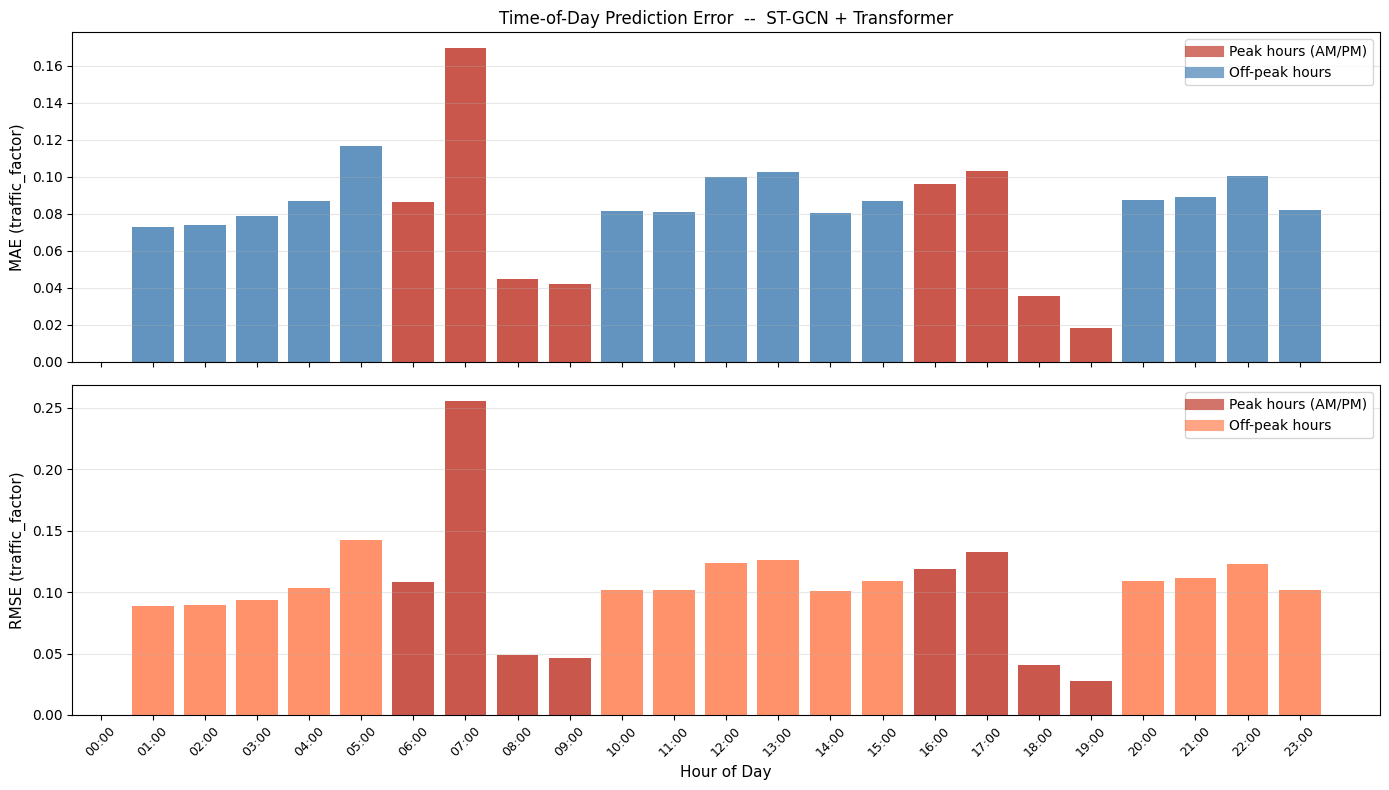

In [16]:
# Cell 16 -- Time-of-day error analysis
test_start_idx = t_val + LOOKBACK
test_ts_idx    = np.arange(test_start_idx, test_start_idx + len(preds_raw))
test_hours     = timestamps.set_index('ts_idx').reindex(test_ts_idx)['hour'].values

h_mae, h_rmse = {}, {}
for h in range(24):
    m = test_hours == h
    h_mae[h]  = float(np.mean(np.abs(trues_raw[m] - preds_raw[m]))) if m.sum() else float('nan')
    h_rmse[h] = float(np.sqrt(np.mean((trues_raw[m] - preds_raw[m]) ** 2))) if m.sum() else float('nan')

peak = [6, 7, 8, 9, 16, 17, 18, 19]   # AM peak + PM peak (Dhaka)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, data, color_peak, color_off, ylabel in [
    (axes[0], h_mae,  '#c0392b', 'steelblue', f'MAE ({PREDICTION_TARGET})'),
    (axes[1], h_rmse, '#c0392b', 'coral',      f'RMSE ({PREDICTION_TARGET})'),
]:
    ax.bar(range(24),
           [data[h] for h in range(24)],
           color=[color_peak if h in peak else color_off for h in range(24)],
           alpha=0.85)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.plot([], [], color=color_peak, lw=8, alpha=0.7, label='Peak hours (AM/PM)')
    ax.plot([], [], color=color_off,  lw=8, alpha=0.7, label='Off-peak hours')
    ax.legend(fontsize=10)

axes[0].set_title('Time-of-Day Prediction Error  --  ST-GCN + Transformer', fontsize=12)
axes[1].set_xlabel('Hour of Day', fontsize=11)
plt.xticks(range(24), [f'{h:02d}:00' for h in range(24)], rotation=45, fontsize=9)
plt.tight_layout()
plt.savefig('tfp_hourly_error.png', dpi=150, bbox_inches='tight')
plt.show()


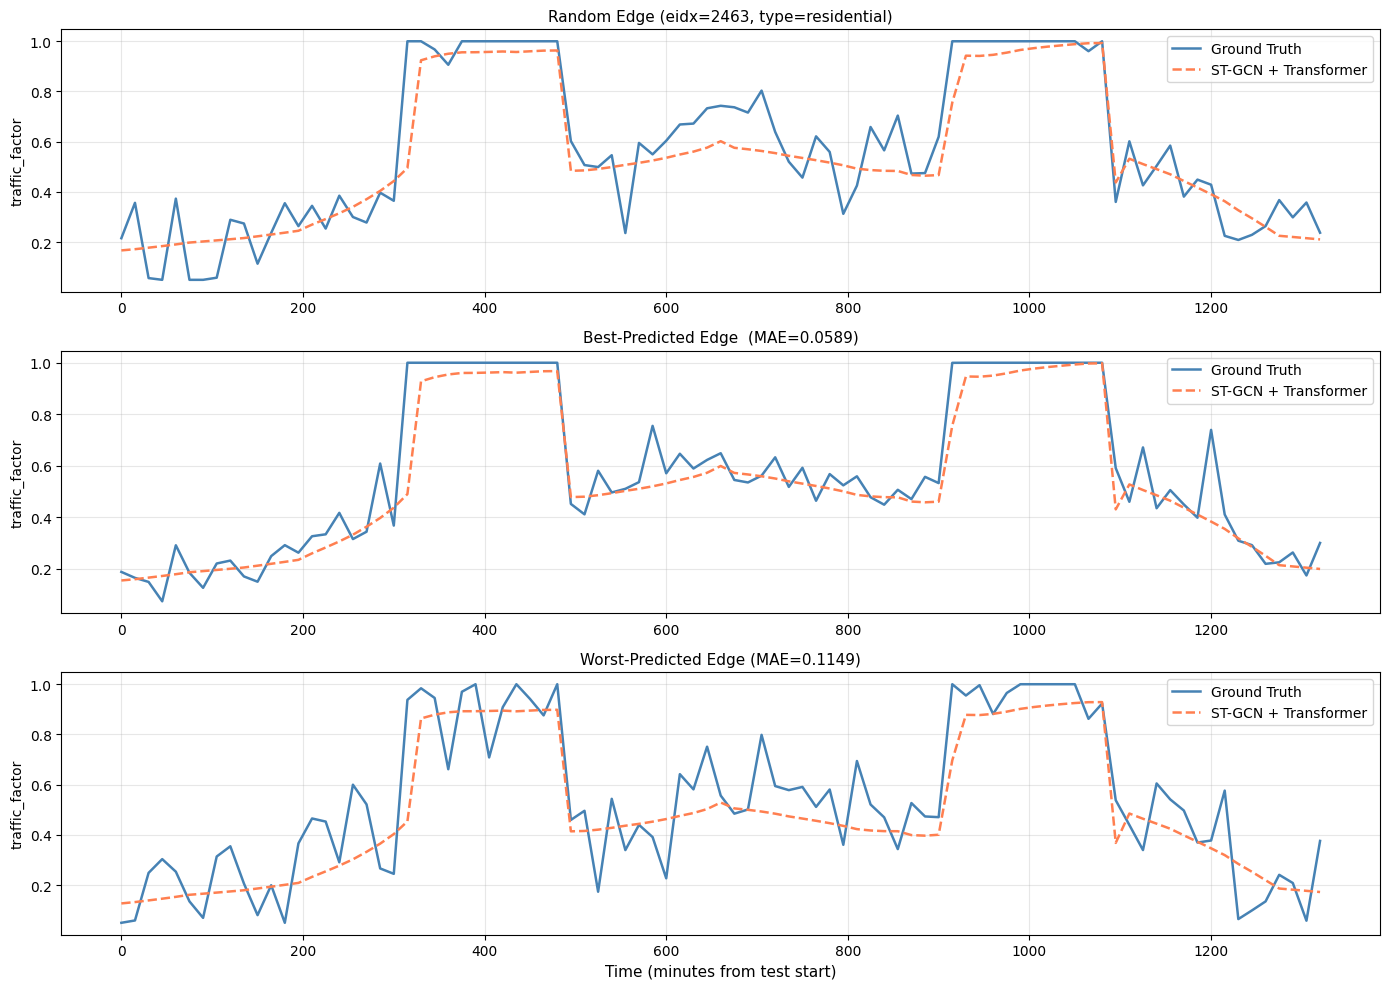

In [17]:
# Cell 17 -- Single-edge prediction vs ground truth (1 day = 96 steps)

_viz_rng   = np.random.default_rng(SEED + 100)
sample_idx = int(_viz_rng.integers(0, N_EDGES))
sample_eid = edge_order[sample_idx]
road_type  = meta_plot.iloc[sample_idx]['road_type']

worst_idx = int(np.argmax(per_edge_mae))
best_idx  = int(np.argmin(per_edge_mae))

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, idx, label in [
    (axes[0], sample_idx, f'Random Edge (eidx={edge_order[sample_idx]}, type={road_type})'),
    (axes[1], best_idx,   f'Best-Predicted Edge  (MAE={per_edge_mae[best_idx]:.4f})'),
    (axes[2], worst_idx,  f'Worst-Predicted Edge (MAE={per_edge_mae[worst_idx]:.4f})'),
]:
    n_plot  = min(96, len(preds_raw))
    time_ax = np.arange(n_plot) * 15
    ax.plot(time_ax, trues_raw[:n_plot, idx], label='Ground Truth',        lw=1.8, color='steelblue')
    ax.plot(time_ax, preds_raw[:n_plot, idx], label='ST-GCN + Transformer', lw=1.8, color='coral', ls='--')
    ax.set_title(label, fontsize=11)
    ax.set_ylabel(PREDICTION_TARGET)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

axes[2].set_xlabel('Time (minutes from test start)', fontsize=11)
plt.tight_layout()
plt.savefig('tfp_single_edge_prediction.png', dpi=150, bbox_inches='tight')
plt.show()


Per-Road-Type Performance Breakdown:


,MAE_mean,MAE_count,RMSE_mean,RMSE_count
rt_str,,,,
road,0.0940,2,0.1199,2
motorway,0.0912,85,0.1182,85
trunk,0.0906,2379,0.1174,2379
secondary,0.0892,3528,0.1166,3528
motorway_link,0.0890,51,0.1172,51
primary,0.0889,2851,0.1156,2851
trunk_link,0.0880,267,0.1161,267
secondary_link,0.0877,285,0.1154,285
primary_link,0.0872,284,0.1146,284


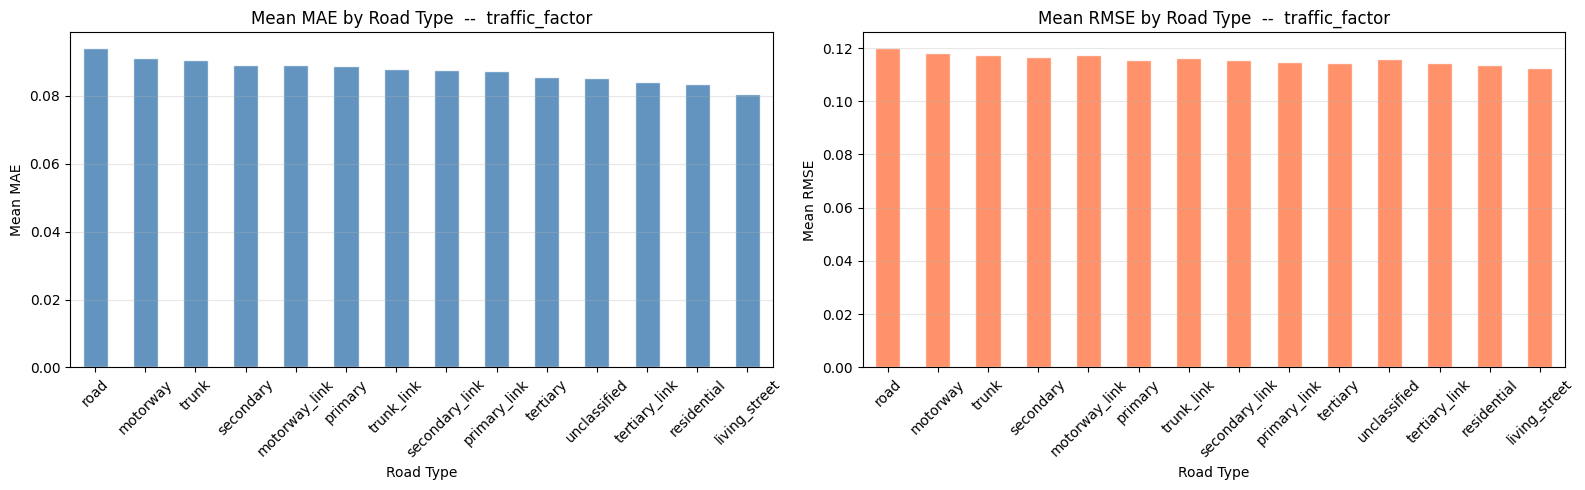

In [18]:
# Cell 18 -- Per-road-type performance breakdown
meta_plot['rt_str'] = meta_plot['road_type'].astype(str)
rt_df = (
    meta_plot.groupby('rt_str')[['per_edge_mae', 'per_edge_rmse']]
    .agg(['mean', 'count'])
    .round(4)
)
rt_df.columns = ['MAE_mean', 'MAE_count', 'RMSE_mean', 'RMSE_count']
rt_df = rt_df.sort_values('MAE_mean', ascending=False)
print('Per-Road-Type Performance Breakdown:')
display(rt_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
rt_df['MAE_mean'].plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_title(f'Mean MAE by Road Type  --  {PREDICTION_TARGET}', fontsize=12)
axes[0].set_xlabel('Road Type'); axes[0].set_ylabel('Mean MAE')
axes[0].tick_params(axis='x', rotation=45); axes[0].grid(True, alpha=0.3, axis='y')

rt_df['RMSE_mean'].plot(kind='bar', ax=axes[1], color='coral', alpha=0.85, edgecolor='white')
axes[1].set_title(f'Mean RMSE by Road Type  --  {PREDICTION_TARGET}', fontsize=12)
axes[1].set_xlabel('Road Type'); axes[1].set_ylabel('Mean RMSE')
axes[1].tick_params(axis='x', rotation=45); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tfp_roadtype_performance.png', dpi=150, bbox_inches='tight')
plt.show()


Benchmark Comparison  --  traffic_factor


,MAE,RMSE,MAPE
Persistence (Last Value),0.1088,0.1678,35.9793
Historical Mean,0.2114,0.2700,54.2260
ST-GCN + Transformer,0.0837,0.1141,29.3134


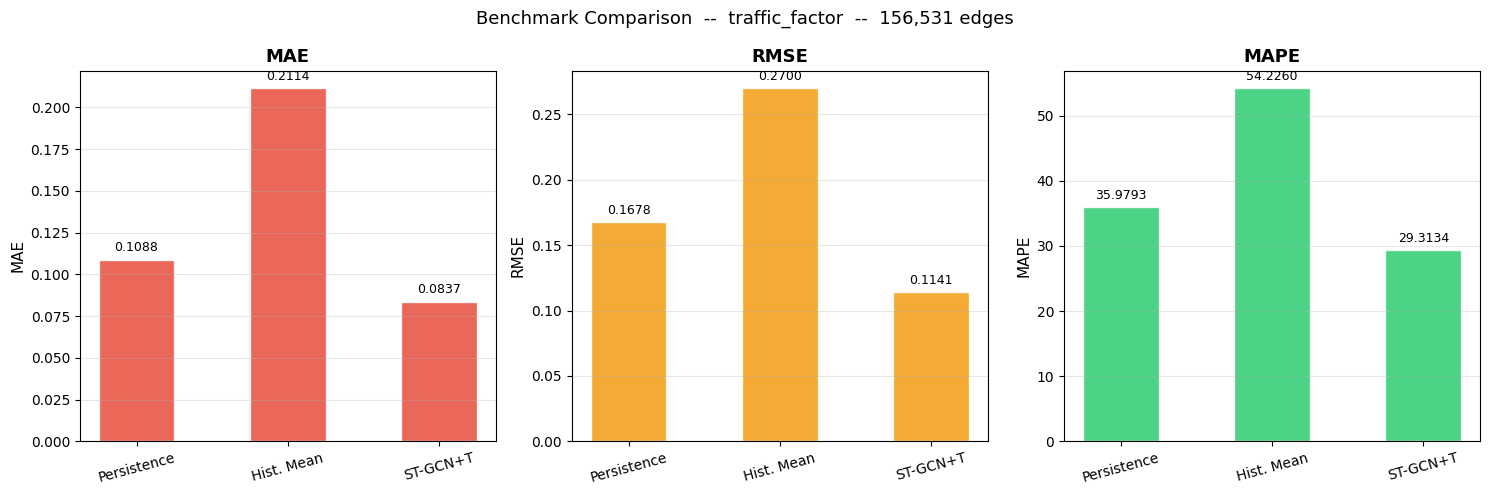

In [19]:
# Cell 19 -- Benchmark: ST-GCN + Transformer vs baselines
lv_list, hm_list, tr_list = [], [], []
for xb, _, yb in test_loader:
    lv_list.append(xb[:, -1, :].numpy())    # persistence: last observed value
    hm_list.append(xb.mean(dim=1).numpy())  # historical mean over lookback window
    tr_list.append(yb[:, 0, :].numpy())

lv_raw  = np.concatenate(lv_list)  * y_std[0] + y_mean[0]
hm_raw  = np.concatenate(hm_list)  * y_std[0] + y_mean[0]
tr2_raw = np.concatenate(tr_list)  * y_std[0] + y_mean[0]
if PREDICTION_TARGET == 'traffic_factor':
    lv_raw = np.clip(lv_raw, 0.0, 1.0)
    hm_raw = np.clip(hm_raw, 0.0, 1.0)

def metrics(yt, yp):
    m_ = np.abs(yt) > 1e-3
    return {
        'MAE':  mean_absolute_error(yt.flatten(), yp.flatten()),
        'RMSE': np.sqrt(mean_squared_error(yt.flatten(), yp.flatten())),
        'MAPE': np.mean(np.abs((yt[m_] - yp[m_]) / yt[m_])) * 100,
    }

results = {
    'Persistence (Last Value)': metrics(tr2_raw, lv_raw),
    'Historical Mean':           metrics(tr2_raw, hm_raw),
    'ST-GCN + Transformer':      metrics(tr2_raw, preds_raw),
}

bench_df = pd.DataFrame(results).T.round(4)
print(f'Benchmark Comparison  --  {PREDICTION_TARGET}')
display(bench_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_bar = ['#e74c3c', '#f39c12', '#2ecc71']
labels_short = ['Persistence', 'Hist. Mean', 'ST-GCN+T']
for ax, metric, col in zip(axes, ['MAE', 'RMSE', 'MAPE'], colors_bar):
    vals = [v[metric] for v in results.values()]
    bars = ax.bar(labels_short, vals, color=col, alpha=0.85, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.015,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.suptitle(f'Benchmark Comparison  --  {PREDICTION_TARGET}  --  {N_EDGES:,} edges', fontsize=13)
plt.tight_layout()
plt.savefig('tfp_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [21]:
# Cell 20 -- Statistical significance testing
from scipy import stats

def diebold_mariano_test(e1, e2, h=1):
    """
    e1: forecast errors for model 1 (our model)
    e2: forecast errors for baseline (persistence)
    h: forecast horizon
    Returns: DM statistic, p-value
    """
    d = np.abs(e1) - np.abs(e2)
    n = len(d)
    d_mean = d.mean()
    # Newey-West autocorrelation-consistent variance estimate
    gamma_0 = np.var(d, ddof=1)
    gamma_k = sum(
        np.cov(d[k:], d[:-k])[0,1] if k > 0 else 0
        for k in range(1, h+1)
    )
    V_d = (gamma_0 + 2 * gamma_k) / n
    dm_stat = d_mean / np.sqrt(max(V_d, 1e-10))
    p_val = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_val

model_errors   = (preds_raw - trues_raw).flatten()
persist_errors = (lv_raw    - tr2_raw).flatten()

dm_stat, dm_pval = diebold_mariano_test(model_errors, persist_errors)
print(f'Diebold-Mariano test (vs. Persistence):')
print(f'  DM statistic: {dm_stat:.4f}')
print(f'  p-value:      {dm_pval:.6f}  {"✓ Significant at p<0.05" if dm_pval < 0.05 else "✗ NOT significant"}')

# Bootstrap CI over per-edge MAE — memory efficient (per_edge_mae from Cell 14)
n_bootstrap = 10000
rng_boot    = np.random.default_rng(SEED)
n_edges     = len(per_edge_mae)
boot_mae    = np.empty(n_bootstrap, dtype=np.float32)

for i in range(n_bootstrap):
    idx         = rng_boot.integers(0, n_edges, size=n_edges)
    boot_mae[i] = per_edge_mae[idx].mean()

ci_low, ci_high = np.percentile(boot_mae, [2.5, 97.5])
print(f'\nMAE Bootstrap 95% CI: [{ci_low:.4f}, {ci_high:.4f}]')
print(f'MAE (point estimate): {mae:.4f}')
print(f'(Any baseline within this interval is not significantly different)')

Diebold-Mariano test (vs. Persistence):
  DM statistic: -647.1621
  p-value:      0.000000  ✓ Significant at p<0.05

MAE Bootstrap 95% CI: [0.0836, 0.0837]
MAE (point estimate): 0.0837
(Any baseline within this interval is not significantly different)


In [20]:
# Cell 21 -- Final results table + save model and plots to Drive

r = results   # already clean keys (no newlines)

summary_df = pd.DataFrame({
    'Metric'               : ['MAE', 'RMSE', 'MAPE (%)'],
    'Persistence'          : [r['Persistence (Last Value)']['MAE'],
                              r['Persistence (Last Value)']['RMSE'],
                              r['Persistence (Last Value)']['MAPE']],
    'Historical Mean'      : [r['Historical Mean']['MAE'],
                              r['Historical Mean']['RMSE'],
                              r['Historical Mean']['MAPE']],
    'ST-GCN + Transformer' : [r['ST-GCN + Transformer']['MAE'],
                              r['ST-GCN + Transformer']['RMSE'],
                              r['ST-GCN + Transformer']['MAPE']],
}).set_index('Metric').round(4)

print('=' * 65)
print(f'  FINAL RESULTS  --  {PREDICTION_TARGET}')
print(f'  Model    : ST-GCN + Transformer  (Graph Neural Network)')
print(f'  N_edges  : {N_EDGES:,}  (complete Dhaka road network, 100%)')
print(f'  Lookback : {LOOKBACK} steps  ({LOOKBACK * 15} min history)')
print(f'  Horizon  : {HORIZON} step   ({HORIZON * 15} min ahead)')
print(f'  Params   : {n_params:,}')
print('=' * 65)
display(summary_df)

base = r['Persistence (Last Value)']
ours = r['ST-GCN + Transformer']
print()
for metric in ['MAE', 'RMSE', 'MAPE']:
    pct = (base[metric] - ours[metric]) / base[metric] * 100
    print(f'  {metric} improvement over Persistence : {pct:.1f}%')

# Save model checkpoint
save_path = os.path.join(BASE_DIR, 'tfp_stgcn_transformer_final.pt')
torch.save({
    'model_state_dict' : model.state_dict(),
    'y_mean'           : y_mean,
    'y_std'            : y_std,
    'edge_order'       : edge_order,
    'config'           : {
        'model'            : 'ST-GCN + Transformer',
        'PREDICTION_TARGET': PREDICTION_TARGET,
        'LOOKBACK'         : LOOKBACK,
        'HORIZON'          : HORIZON,
        'D_MODEL'          : D_MODEL,
        'N_HEADS'          : N_HEADS,
        'N_LAYERS'         : N_LAYERS,
        'MAX_EDGES'        : MAX_EDGES,
        'N_EDGES'          : N_EDGES,
        'n_params'         : n_params,
    },
    'results'          : {
        'MAE' : ours['MAE'],
        'RMSE': ours['RMSE'],
        'MAPE': ours['MAPE'],
    },
}, save_path)
print(f'\nModel saved : {save_path}')

# Copy all plots to Drive
import shutil
plot_dir = os.path.join(BASE_DIR, 'plots')
os.makedirs(plot_dir, exist_ok=True)
plots = [
    'tfp_training_curve.png',
    'tfp_per_edge_error_dist.png',
    'tfp_spatial_error_heatmap.png',
    'tfp_hourly_error.png',
    'tfp_single_edge_prediction.png',
    'tfp_roadtype_performance.png',
    'tfp_benchmark_comparison.png',
]
for fname in plots:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(plot_dir, fname))
        print(f'  Saved: {fname}')
print('All outputs saved to Google Drive.')


  FINAL RESULTS  --  traffic_factor
  Model    : ST-GCN + Transformer  (Graph Neural Network)
  N_edges  : 156,531  (complete Dhaka road network, 100%)
  Lookback : 12 steps  (180 min history)
  Horizon  : 1 step   (15 min ahead)
  Params   : 181,505


,Persistence,Historical Mean,ST-GCN + Transformer
Metric,,,
MAE,0.1088,0.2114,0.0837
RMSE,0.1678,0.2700,0.1141
MAPE (%),35.9793,54.2260,29.3134



  MAE improvement over Persistence : 23.1%
  RMSE improvement over Persistence : 32.0%
  MAPE improvement over Persistence : 18.5%

Model saved : /content/drive/MyDrive/traffic_flow_prediction/tfp_stgcn_transformer_final.pt
  Saved: tfp_training_curve.png
  Saved: tfp_per_edge_error_dist.png
  Saved: tfp_spatial_error_heatmap.png
  Saved: tfp_hourly_error.png
  Saved: tfp_single_edge_prediction.png
  Saved: tfp_roadtype_performance.png
  Saved: tfp_benchmark_comparison.png
All outputs saved to Google Drive.
